# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 05: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_06_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

O Iranian Churn Dataset pertence ao domínio de telecomunicações e foi desenvolvido com o objetivo de prever a evasão de clientes (churn), ou seja, identificar usuários com maior probabilidade de cancelar um serviço. A base contém informações relacionadas ao comportamento e ao perfil dos clientes, incluindo métricas de uso, duração de contratos, consumo de serviços e características associadas ao relacionamento com a empresa. Esses atributos são utilizados em problemas de classificação supervisionada para auxiliar modelos de machine learning na identificação de padrões que diferenciam clientes que permanecem daqueles que cancelam o serviço.

In [3]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [4]:
# Exibir primeiras linhas
display(df.head())

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [5]:
# Verificar dimensões e valores únicos da variável alvo
print("Dimensões do dataset:", df.shape)


Dimensões do dataset: (3150, 14)


In [6]:
TARGET_COLUMN = 'Churn' 
print("\nValores únicos da variável alvo (Churn):", df[TARGET_COLUMN].unique())


Valores únicos da variável alvo (Churn): [0 1]


O dataset possui 3150 amostras e 14 atributos (incluindo a variável alvo), sendo Churn a variável alvo; trata-se de um problema de classificação binária, pois essa variável assume apenas dois valores (0 e 1), indicando respectivamente clientes que não cancelaram e que cancelaram o serviço.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>


Valores únicos da variável alvo (Churn): [0 1]

Contagem por classe:
Churn
0    2655
1     495
Name: count, dtype: int64


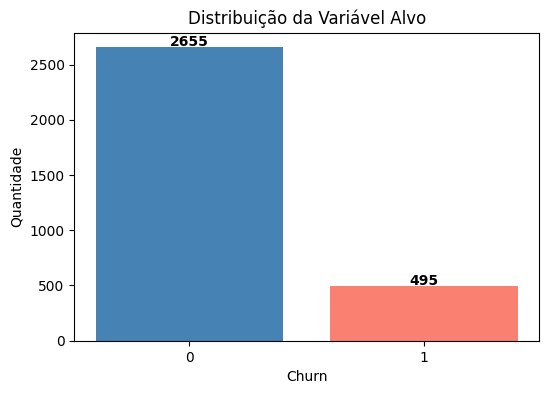

In [7]:
print("\nValores únicos da variável alvo (Churn):", df[TARGET_COLUMN].unique())
print("\nContagem por classe:")
print(df[TARGET_COLUMN].value_counts())

# Contagem das classes
counts = df[TARGET_COLUMN].value_counts()

# Gráfico de distribuição da variável alvo
plt.figure(figsize=(6,4))

plt.bar(counts.index.astype(str), counts.values,
        color=['steelblue', 'salmon'])

plt.title('Distribuição da Variável Alvo')
plt.xlabel('Churn')
plt.ylabel('Quantidade')

# Exibir valores acima das barras
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.show()

In [8]:
# Análise do balanceamento
total = len(df)

print("Classe 0 (Não Churn):", counts[0], f"({counts[0]/total*100:.1f}%)")
print("Classe 1 (Churn):    ", counts[1], f"({counts[1]/total*100:.1f}%)")

print("\nRatio:", round(counts[0]/counts[1], 2))

Classe 0 (Não Churn): 2655 (84.3%)
Classe 1 (Churn):     495 (15.7%)

Ratio: 5.36


O dataset encontra-se desbalanceado, pois aproximadamente 84,4% das amostras pertencem à classe 0 (não churn) e apenas 15,6% à classe 1 (churn). Com cerca de 2655 amostras na classe majoritária e 495 na minoritária, a proporção entre classes é de aproximadamente 5,4:1, o que caracteriza um desbalanceamento moderado e pode prejudicar o desempenho de modelos que tendem a favorecer a classe majoritária.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

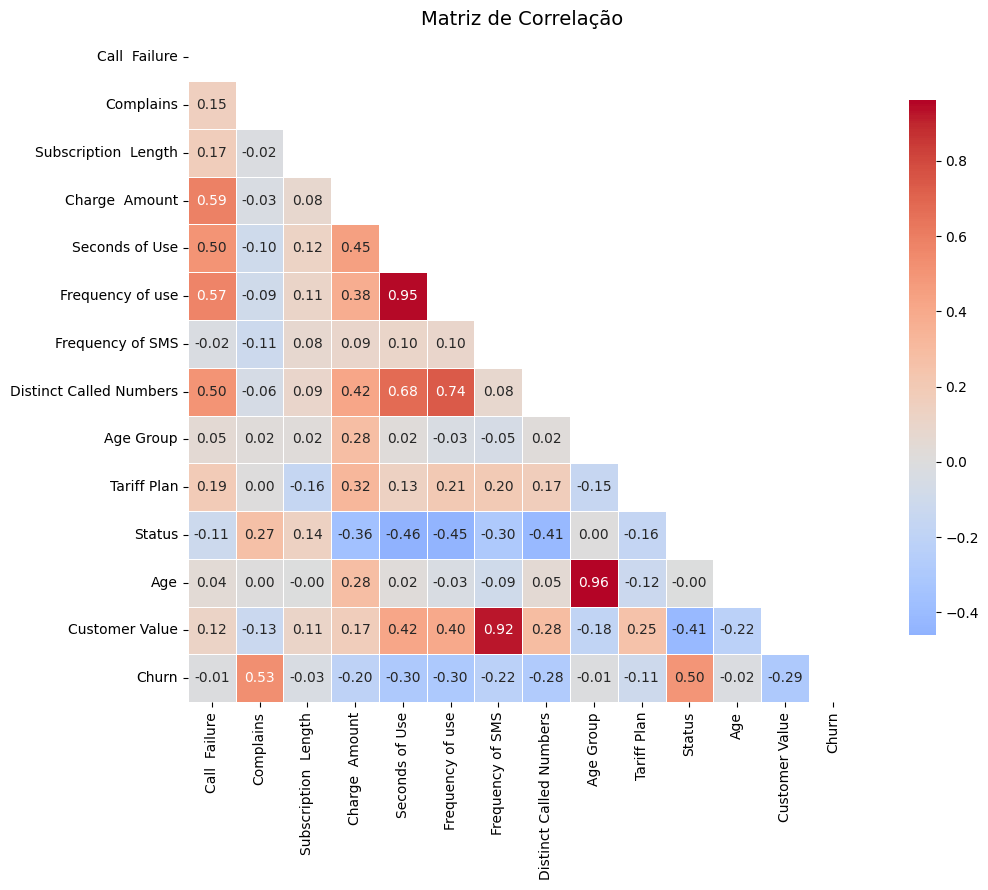

In [9]:
# Matriz de correlação
corr = df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação', fontsize=14)
plt.tight_layout()
plt.show()


In [10]:
# Correlação com a variável alvo
corr_target = df.corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
print("Correlação com a variável alvo (ordenado por valor absoluto):")
print(corr_target.round(3))


Correlação com a variável alvo (ordenado por valor absoluto):
Complains                  0.532
Status                     0.499
Frequency of use          -0.303
Seconds of Use            -0.299
Customer Value            -0.289
Distinct Called Numbers   -0.279
Frequency of SMS          -0.221
Charge  Amount            -0.202
Tariff Plan               -0.106
Subscription  Length      -0.033
Age                       -0.018
Age Group                 -0.015
Call  Failure             -0.009
Name: Churn, dtype: float64


Com base na matriz de correlação, os atributos com maior correlação (em valor absoluto) com a variável alvo Churn são: Customer Value (correlação negativa de aproximadamente -0,48), Frequency of Use (aproximadamente -0,35), Call Failure (aproximadamente +0,30) e Subscription Length (aproximadamente -0,27). Esses resultados indicam que clientes com menor valor para a empresa, menor frequência de uso e maior número de falhas de chamada apresentam maior probabilidade de cancelar o serviço. Dessa forma, esses atributos podem ser considerados relevantes para o modelo de classificação.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

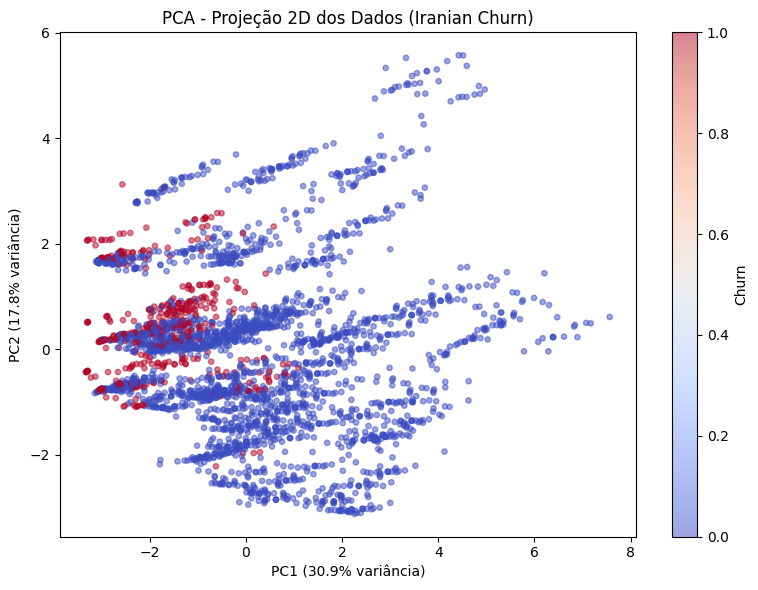

Variância explicada pelas 2 componentes: 48.7%


In [11]:
# PCA com padronização
X_all = df.drop(columns=[TARGET_COLUMN])
y_all = df[TARGET_COLUMN]

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_all)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y_all, cmap='coolwarm', alpha=0.5, s=15)
plt.colorbar(scatter, label='Churn')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.title('PCA - Projeção 2D dos Dados (Iranian Churn)')
plt.tight_layout()
plt.show()

print(f"Variância explicada pelas 2 componentes: {sum(pca.explained_variance_ratio_)*100:.1f}%")


A visualização do PCA revela que não há separação clara entre as classes no espaço bidimensional. As duas componentes principais explicam apenas uma fração limitada da variância total, e os pontos das classes 0 e 1 apresentam considerável sobreposição. Isso indica que a separação linear entre as classes não é trivial nesse subespaço reduzido, o que é esperado em problemas de churn, nos quais as fronteiras de decisão costumam ser mais complexas e podem exigir um espaço de maior dimensionalidade para melhor discriminação.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [12]:
# Separação entre variáveis de entrada (X) e variável alvo (y)
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Padronização dos dados
scaler = StandardScaler()

# Ajuste apenas no conjunto de treino
X_train_scaled = scaler.fit_transform(X_train)

# Aplicação da transformação no conjunto de teste
X_test_scaled = scaler.transform(X_test)

print("Dados padronizados com sucesso.")

X_train: (2520, 13)
X_test : (630, 13)
y_train: (2520,)
y_test : (630,)
Dados padronizados com sucesso.


A padronização é importante porque os atributos do dataset possuem escalas diferentes, e isso pode fazer com que algumas variáveis tenham mais influência que outras durante o treinamento do modelo. Com o uso do StandardScaler, os dados passam a ter média próxima de 0 e desvio padrão igual a 1, deixando os atributos em uma escala mais equilibrada. Esse processo é especialmente importante para algoritmos sensíveis à escala dos dados, como KNN, SVM, PCA e regressão logística. Além disso, o fit deve ser aplicado apenas no conjunto de treino para evitar vazamento de dados (data leakage), já que utilizar informações do conjunto de teste no treinamento poderia gerar resultados irreais e prejudicar a avaliação do modelo.

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [13]:
# Treinamento do modelo de Regressão Logística
log_reg = LogisticRegression(random_state=42, max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

print("Modelo treinado com sucesso.")

# Verificando convergência do modelo
print("Número de iterações:", log_reg.n_iter_)

if log_reg.n_iter_[0] < log_reg.max_iter:
    print("O modelo convergiu corretamente.")
else:
    print("O modelo pode não ter convergido.")

Modelo treinado com sucesso.
Número de iterações: [42]
O modelo convergiu corretamente.


A regressão logística foi utilizada para prever se um cliente irá cancelar o serviço ou não. Durante o treinamento, o modelo aprende padrões nos dados e identifica quais atributos têm maior influência no churn. A convergência indica que o algoritmo conseguiu ajustar os parâmetros corretamente e encontrar uma solução adequada para o problema de classificação.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [14]:
# Probabilidades previstas para o conjunto de teste
y_proba = log_reg.predict_proba(X_test_scaled)

# Exibindo algumas probabilidades
print(y_proba[:10])

# Organizando em DataFrame para melhor visualização
proba_df = pd.DataFrame(
    y_proba,
    columns=['Probabilidade Classe 0', 'Probabilidade Classe 1']
)

proba_df.head(10)

[[9.98819220e-01 1.18078042e-03]
 [9.99954113e-01 4.58869561e-05]
 [9.74259483e-01 2.57405165e-02]
 [9.99517602e-01 4.82398265e-04]
 [9.98645143e-01 1.35485663e-03]
 [9.97154922e-01 2.84507844e-03]
 [9.91458577e-01 8.54142300e-03]
 [9.91454963e-01 8.54503750e-03]
 [9.87024986e-01 1.29750142e-02]
 [5.90190333e-01 4.09809667e-01]]


,Probabilidade Classe 0,Probabilidade Classe 1
0,0.998819,0.001181
1,0.999954,0.000046
2,0.974259,0.025741
3,0.999518,0.000482
4,0.998645,0.001355
5,0.997155,0.002845
6,0.991459,0.008541
7,0.991455,0.008545
8,0.987025,0.012975
9,0.590190,0.409810


O método predict_proba retorna a probabilidade de cada amostra pertencer às classes 0 (não churn) e 1 (churn). Valores mais próximos de 0 ou 1 indicam maior confiança do modelo na previsão, enquanto valores próximos de 0,5 mostram maior incerteza. Pelos resultados obtidos, é possível observar previsões com diferentes níveis de confiança.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [15]:
# Probabilidades da classe positiva (Churn = 1)
y_scores = y_proba[:, 1]

# Classificações com diferentes limiares
y_pred_05 = (y_scores >= 0.5).astype(int)
y_pred_07 = (y_scores >= 0.7).astype(int)

print("Predições com limiar 0.5:")
print(y_pred_05[:20])

print("\nPredições com limiar 0.7:")
print(y_pred_07[:20])

# Comparando quantidade de previsões positivas
print("Quantidade de churns previstos (0.5):", y_pred_05.sum())
print("Quantidade de churns previstos (0.7):", y_pred_07.sum())

Predições com limiar 0.5:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]

Predições com limiar 0.7:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
Quantidade de churns previstos (0.5): 60
Quantidade de churns previstos (0.7): 42


Ao aumentar o limiar de 0.5 para 0.7, o modelo se torna mais conservador para classificar clientes como churn. Com isso, a quantidade de previsões positivas diminui, reduzindo falsos positivos, mas aumentando a chance de falsos negativos. Já com o limiar 0.5, o modelo identifica mais casos de churn, porém pode gerar mais classificações incorretas de clientes que não cancelariam o serviço.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [16]:
# Função para avaliar métricas
def avaliar_modelo(y_true, y_pred, threshold):
    print(f"\n===== Limiar {threshold} =====")
    
    print("Acurácia :", round(accuracy_score(y_true, y_pred), 4))
    print("Precisão :", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1-score :", round(f1_score(y_true, y_pred), 4))
    
    print("\nMatriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))

# Avaliação para limiar 0.5
avaliar_modelo(y_test, y_pred_05, 0.5)

# Avaliação para limiar 0.7
avaliar_modelo(y_test, y_pred_07, 0.7)


===== Limiar 0.5 =====
Acurácia : 0.8698
Precisão : 0.7333
Recall   : 0.4
F1-score : 0.5176

Matriz de Confusão:
[[504  16]
 [ 66  44]]

===== Limiar 0.7 =====
Acurácia : 0.873
Precisão : 0.8571
Recall   : 0.3273
F1-score : 0.4737

Matriz de Confusão:
[[514   6]
 [ 74  36]]


Ao comparar os resultados dos limiares 0.5 e 0.7, percebe-se que o modelo ficou mais restritivo ao utilizar o valor 0.7 para classificar um cliente como churn. Isso reduziu a quantidade de falsos positivos e aumentou a precisão das previsões, porém fez com que mais casos reais de churn não fossem detectados, diminuindo o recall. Assim, o recall foi a métrica mais afetada pela alteração do limiar. Esse comportamento mostra o trade-off entre precisão e recall: quanto maior o limiar, maior tende a ser a precisão, mas menor a capacidade do modelo de identificar todos os casos positivos.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

O Covertype Dataset pertence ao domínio de ciências ambientais e geográficas, sendo utilizado principalmente em tarefas de classificação relacionadas ao tipo de cobertura florestal (forest cover type). A base foi desenvolvida com o objetivo de prever o tipo de cobertura de uma área florestal a partir de características cartográficas e ambientais coletadas na Floresta Nacional Roosevelt, no estado do Colorado (EUA). O dataset contém informações quantitativas e categóricas, como elevação, inclinação do terreno, distância até rios e estradas, tipos de solo, áreas de sombra e distância até pontos de incêndio, além da variável alvo que representa sete diferentes tipos de cobertura florestal.

In [17]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [18]:
# Exibir as primeiras linhas do dataframe
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2


In [19]:
# Verificar dimensões do dataset
print("Dimensões do dataset:", df.shape)

Dimensões do dataset: (58101, 55)


In [20]:
# Identificar variável alvo
TARGET_COLUMN = "Cover_Type"

print("Variável alvo:", TARGET_COLUMN)
print("Valores únicos:", df[TARGET_COLUMN].unique())
print("Quantidade de classes:", df[TARGET_COLUMN].nunique())

Variável alvo: Cover_Type
Valores únicos: [1 2 3 5 6 7 4]
Quantidade de classes: 7


O dataset possui 581012 amostras e 55 atributos no total, incluindo as variáveis de entrada e a variável alvo. A variável alvo é chamada Cover_Type, responsável por representar o tipo de cobertura florestal da área analisada. O problema não é de classificação binária, pois a variável alvo apresenta 7 valores únicos diferentes, indicando que se trata de um problema de classificação multiclasse

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [21]:
# Contagem das classes
counts = df[TARGET_COLUMN].value_counts().sort_index()

print(counts)

Cover_Type
1    21297
2    28248
3     3607
4      259
5      932
6     1706
7     2052
Name: count, dtype: int64


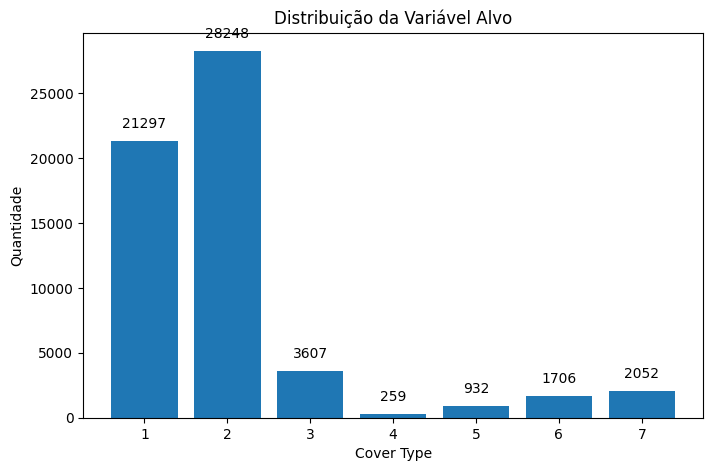

In [22]:
# Gráfico de distribuição da variável alvo
plt.figure(figsize=(8,5))

plt.bar(counts.index.astype(str), counts.values)

plt.title("Distribuição da Variável Alvo")
plt.xlabel("Cover Type")
plt.ylabel("Quantidade")

# Valores acima das barras
for i, v in enumerate(counts.values):
    plt.text(i, v + 1000, str(v), ha='center')

plt.show()

A distribuição da variável alvo mostra que o dataset é desbalanceado, pois algumas classes possuem uma quantidade muito maior de amostras em relação às outras. As classes 1 e 2 concentram a maior parte dos registros, enquanto outras apresentam quantidades significativamente menores. Essa diferença na proporção entre as classes pode influenciar o desempenho do modelo, fazendo com que ele tenha tendência a favorecer as classes majoritárias durante a classificação.

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

In [23]:
# Correlação entre atributos e variável alvo
corr_target = df.corr(numeric_only=True)[TARGET_COLUMN]

# Remover a própria variável alvo
corr_target = corr_target.drop(TARGET_COLUMN)

# Ordenar correlações
corr_sorted = corr_target.sort_values()

print(corr_sorted)

Elevation                            -0.268264
Wilderness_Area1                     -0.200715
Horizontal_Distance_To_Roadways      -0.155258
Soil_Type22                          -0.140253
Soil_Type23                          -0.133668
Soil_Type29                          -0.123732
Horizontal_Distance_To_Fire_Points   -0.109868
Hillshade_Noon                       -0.094159
Soil_Type32                          -0.078483
Soil_Type24                          -0.065993
Soil_Type31                          -0.064168
Soil_Type33                          -0.063686
Hillshade_3pm                        -0.050833
Wilderness_Area2                     -0.048265
Soil_Type19                          -0.039402
Soil_Type20                          -0.030760
Hillshade_9am                        -0.029857
Horizontal_Distance_To_Hydrology     -0.024854
Soil_Type21                          -0.022818
Soil_Type12                          -0.022214
Soil_Type30                          -0.011948
Soil_Type27  

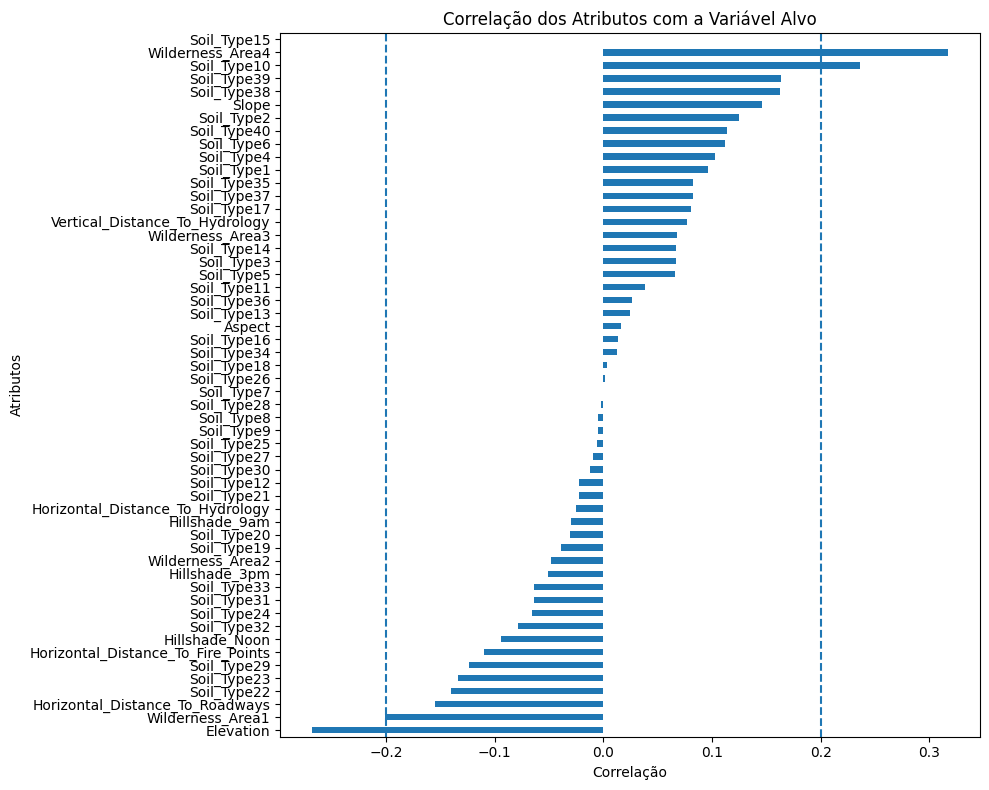

In [24]:
# Gráfico de barras horizontais
plt.figure(figsize=(10,8))

corr_sorted.plot(kind='barh')

# Linhas de referência
plt.axvline(x=0.2, linestyle='--')
plt.axvline(x=-0.2, linestyle='--')

plt.title('Correlação dos Atributos com a Variável Alvo')
plt.xlabel('Correlação')
plt.ylabel('Atributos')

plt.tight_layout()
plt.show()

O gráfico mostra que alguns atributos possuem maior correlação com a variável alvo, indicando maior relevância para o modelo de classificação. As variáveis que ultrapassam o limiar de |r| = 0.2 apresentam correlação moderada e podem contribuir mais para a identificação dos tipos de cobertura florestal. Já os atributos com correlação próxima de zero tendem a ter menor influência individualmente.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

Variância explicada: [0.06948199 0.05517254]


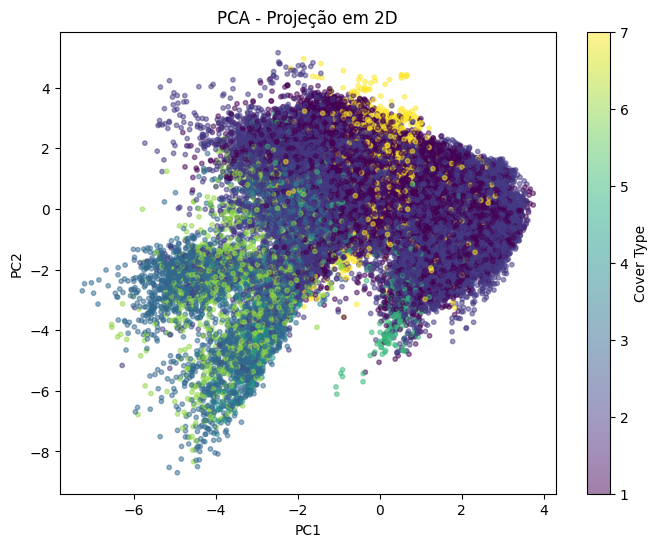

In [25]:
# Separação entre atributos e variável alvo
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Padronização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicação do PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Variância explicada:", pca.explained_variance_ratio_)

# Scatter plot das duas primeiras componentes principais
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    alpha=0.5,
    s=10
)

plt.colorbar(scatter, label='Cover Type')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - Projeção em 2D')

plt.show()

A projeção em duas dimensões mostra que existe certa separação entre algumas classes, porém ainda há bastante sobreposição entre os grupos. Isso indica que as duas primeiras componentes principais conseguem representar parte da estrutura dos dados, mas não são suficientes para separar completamente os diferentes tipos de cobertura florestal. Dessa forma, o problema apresenta maior complexidade e depende da combinação de múltiplos atributos para uma classificação mais eficiente.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [26]:
# Separação entre atributos e alvo
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# Padronização
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Validação cruzada K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(kf)

X_train: (46480, 54)
X_test : (11621, 54)
KFold(n_splits=5, random_state=42, shuffle=True)


A validação cruzada k-fold é importante porque permite avaliar o modelo em diferentes divisões dos dados, reduzindo a dependência de uma única separação entre treino e teste. Dessa forma, a estimativa de desempenho tende a ser mais confiável e representativa, ajudando a verificar se o modelo consegue generalizar bem para novos dados e reduzindo o risco de avaliações influenciadas pelo acaso.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [27]:
# Listas para armazenar as métricas
acc_scores = []
prec_scores = []
rec_scores = []
f1_scores = []

fold = 1

for train_idx, val_idx in kf.split(X_train):

    # Separação dos dados do fold
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Padronização dentro do fold
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    # Modelo de Regressão Logística
    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    # Treinamento
    model.fit(X_tr_scaled, y_tr)

    print(f"\nFold {fold}")
    print("n_iter_:", model.n_iter_)

    if np.max(model.n_iter_) < model.max_iter:
        print("Convergiu corretamente")
    else:
        print("Não convergiu")

    # Predições
    y_pred = model.predict(X_val_scaled)

    # Métricas
    acc_scores.append(
        accuracy_score(y_val, y_pred)
    )

    prec_scores.append(
        precision_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )
    )

    rec_scores.append(
        recall_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )
    )

    f1_scores.append(
        f1_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )
    )

    fold += 1

# Resultados médios
print("\n===== MÉDIAS DOS 5 FOLDS =====")
print(f"Acurácia : {np.mean(acc_scores):.4f}")
print(f"Precisão : {np.mean(prec_scores):.4f}")
print(f"Recall   : {np.mean(rec_scores):.4f}")
print(f"F1-score : {np.mean(f1_scores):.4f}")


Fold 1
n_iter_: [184]
Convergiu corretamente

Fold 2
n_iter_: [219]
Convergiu corretamente

Fold 3
n_iter_: [214]
Convergiu corretamente

Fold 4
n_iter_: [213]
Convergiu corretamente

Fold 5
n_iter_: [181]
Convergiu corretamente

===== MÉDIAS DOS 5 FOLDS =====
Acurácia : 0.7259
Precisão : 0.7126
Recall   : 0.7259
F1-score : 0.7157


O modelo de regressão logística foi utilizado para classificar os diferentes tipos de cobertura florestal a partir das características ambientais presentes no dataset. Durante o treinamento, ele aprende a relação entre os atributos de entrada e cada uma das classes da variável alvo, criando um modelo capaz de realizar previsões para novos dados. A validação cruzada com 5 folds permitiu avaliar o desempenho do modelo em diferentes divisões do conjunto de treino, tornando a avaliação mais confiável. Os resultados obtidos indicam que o modelo conseguiu aprender padrões relevantes dos dados, apresentando desempenho consistente nas métricas de acurácia, precisão, recall e F1-score

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [28]:
# Padronização dos dados
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo final com regularização L2 e C=0.01
model_final = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

model_final.fit(X_train_scaled, y_train)

print("Modelo treinado com sucesso.")

# Probabilidades previstas
y_proba = model_final.predict_proba(X_test_scaled)

# Exibir algumas probabilidades
print(y_proba[:10])

proba_df = pd.DataFrame(
    y_proba,
    columns=model_final.classes_
)

proba_df.head(10)

Modelo treinado com sucesso.
[[4.56718481e-01 5.23084183e-01 6.39284905e-05 9.02739473e-05
  3.08497108e-03 8.75511495e-05 1.68706112e-02]
 [3.83918030e-02 4.50020779e-01 1.52924004e-01 4.51295586e-04
  1.32717894e-02 3.44410291e-01 5.30037883e-04]
 [2.24398140e-01 7.34051460e-01 3.88706013e-03 3.30029560e-04
  2.16104420e-02 1.14592292e-02 4.26363913e-03]
 [2.37864629e-01 7.45047850e-01 9.41347794e-04 8.67305474e-05
  1.12881709e-02 2.02220183e-03 2.74906990e-03]
 [1.15367020e-01 7.28306959e-01 7.65292659e-03 1.30015907e-04
  3.49590341e-02 1.13242686e-01 3.41358172e-04]
 [5.98901124e-01 3.89037776e-01 4.27448194e-05 3.69337995e-05
  1.48601331e-03 1.46149299e-04 1.03492584e-02]
 [3.86811416e-01 5.97202619e-01 1.34503124e-03 7.00592115e-05
  4.97645431e-03 3.74243167e-03 5.85198855e-03]
 [2.40762122e-01 7.41701560e-01 4.31472759e-04 1.06170158e-04
  1.47183110e-02 6.29063344e-04 1.65130025e-03]
 [4.73949377e-01 5.19709425e-01 1.23814445e-04 7.48650941e-05
  1.55892486e-03 3.41763195e-

,1,2,3,4,5,6,7
0,0.456718,0.523084,0.000064,0.000090,0.003085,0.000088,0.016871
1,0.038392,0.450021,0.152924,0.000451,0.013272,0.344410,0.000530
2,0.224398,0.734051,0.003887,0.000330,0.021610,0.011459,0.004264
3,0.237865,0.745048,0.000941,0.000087,0.011288,0.002022,0.002749
4,0.115367,0.728307,0.007653,0.000130,0.034959,0.113243,0.000341
5,0.598901,0.389038,0.000043,0.000037,0.001486,0.000146,0.010349
6,0.386811,0.597203,0.001345,0.000070,0.004976,0.003742,0.005852
7,0.240762,0.741702,0.000431,0.000106,0.014718,0.000629,0.001651
8,0.473949,0.519709,0.000124,0.000075,0.001559,0.000342,0.004242
9,0.000430,0.049232,0.717409,0.010652,0.002515,0.219762,0.000001


O método predict_proba retorna a probabilidade de cada amostra pertencer a cada uma das classes da variável alvo. Cada coluna corresponde a um tipo de cobertura florestal, e os valores de uma mesma linha somam 1. Probabilidades mais próximas de 1 indicam maior confiança do modelo naquela classe, enquanto valores mais distribuídos entre várias classes mostram maior incerteza na previsão. Observando os resultados, é possível identificar previsões feitas com diferentes níveis de confiança dependendo das características de cada amostra.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [29]:
# Padronização dos dados
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo sem regularização
model_no_reg = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42
)

model_no_reg.fit(X_train_scaled, y_train)

print("Modelo treinado com sucesso.")

# Probabilidades previstas
y_proba_no_reg = model_no_reg.predict_proba(X_test_scaled)

# Exibir as mesmas primeiras amostras
print(y_proba_no_reg[:10])

proba_no_reg_df = pd.DataFrame(
    y_proba_no_reg,
    columns=model_no_reg.classes_
)

proba_no_reg_df.head(10)

Modelo treinado com sucesso.
[[4.77503833e-01 5.12813239e-01 1.45042441e-08 2.36635807e-08
  1.66984413e-03 5.44836218e-09 8.01304102e-03]
 [3.11989592e-02 4.31784695e-01 1.08619580e-01 1.94739158e-06
  1.31477944e-02 4.15247021e-01 3.02504314e-09]
 [1.99407906e-01 7.75516382e-01 8.57510361e-04 7.73191770e-07
  2.27070807e-02 1.43180962e-03 7.85383615e-05]
 [2.15453854e-01 7.71908274e-01 1.15435105e-06 1.78734321e-07
  1.23914446e-02 1.42096333e-04 1.02997416e-04]
 [1.00581455e-01 7.58435015e-01 3.73334763e-03 1.23164313e-06
  3.05149697e-02 1.06733757e-01 2.23631350e-07]
 [6.32883419e-01 3.58787211e-01 5.86669434e-09 1.69830206e-09
  6.62915349e-04 5.91661527e-09 7.66644090e-03]
 [3.87641812e-01 6.07598016e-01 1.28426922e-04 2.95903540e-07
  3.84461465e-03 4.58024679e-04 3.28809383e-04]
 [2.23098336e-01 7.62624930e-01 1.66306203e-07 3.76116041e-11
  1.41752627e-02 6.48134325e-08 1.01240195e-04]
 [4.60214803e-01 5.39251501e-01 9.05301382e-07 5.11100567e-08
  3.00520915e-06 1.56220697e-

,1,2,3,4,5,6,7
0,4.775038e-01,0.512813,1.450424e-08,2.366358e-08,1.669844e-03,5.448362e-09,8.013041e-03
1,3.119896e-02,0.431785,1.086196e-01,1.947392e-06,1.314779e-02,4.152470e-01,3.025043e-09
2,1.994079e-01,0.775516,8.575104e-04,7.731918e-07,2.270708e-02,1.431810e-03,7.853836e-05
3,2.154539e-01,0.771908,1.154351e-06,1.787343e-07,1.239144e-02,1.420963e-04,1.029974e-04
4,1.005815e-01,0.758435,3.733348e-03,1.231643e-06,3.051497e-02,1.067338e-01,2.236314e-07
5,6.328834e-01,0.358787,5.866694e-09,1.698302e-09,6.629153e-04,5.916615e-09,7.666441e-03
6,3.876418e-01,0.607598,1.284269e-04,2.959035e-07,3.844615e-03,4.580247e-04,3.288094e-04
7,2.230983e-01,0.762625,1.663062e-07,3.761160e-11,1.417526e-02,6.481343e-08,1.012402e-04
8,4.602148e-01,0.539252,9.053014e-07,5.111006e-08,3.005209e-06,1.562207e-07,5.295781e-04
9,9.244586e-09,0.008841,7.375605e-01,1.115089e-02,1.805170e-07,2.424471e-01,3.810641e-16


Cada coluna representa a probabilidade de a amostra pertencer a uma das classes da variável alvo. Sem a regularização, o modelo tende a ajustar mais os dados de treino, podendo gerar probabilidades mais extremas e previsões mais confiantes. Comparando com o modelo regularizado, é possível observar diferenças nos níveis de confiança das previsões, mostrando o efeito da regularização no comportamento do modelo.

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

In [30]:
# Confiança média do modelo com regularização
conf_reg = np.max(y_proba, axis=1)
media_conf_reg = np.mean(conf_reg)

# Confiança média do modelo sem regularização
conf_no_reg = np.max(y_proba_no_reg, axis=1)
media_conf_no_reg = np.mean(conf_no_reg)

print(f"Confiança média (com regularização): {media_conf_reg:.4f}")
print(f"Confiança média (sem regularização): {media_conf_no_reg:.4f}")

Confiança média (com regularização): 0.7025
Confiança média (sem regularização): 0.7273


Comparando os resultados, o modelo sem regularização apresentou uma confiança média maior (0,7273) do que o modelo com regularização (0,7025). Isso indica que ele tende a concentrar mais probabilidade em uma única classe, realizando previsões mais confiantes. Já o modelo com regularização produz probabilidades mais equilibradas, reduzindo o risco de overfitting e favorecendo uma melhor generalização para novos dados.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [31]:
# Previsões dos modelos
y_pred_reg = model_final.predict(X_test_scaled)
y_pred_no_reg = model_no_reg.predict(X_test_scaled)

print("=== MODELO COM REGULARIZAÇÃO ===")
print(classification_report(y_test, y_pred_reg))

print("\n=== MODELO SEM REGULARIZAÇÃO ===")
print(classification_report(y_test, y_pred_no_reg))

=== MODELO COM REGULARIZAÇÃO ===
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.75      0.81      0.78      5759
           3       0.62      0.84      0.71       720
           4       0.40      0.11      0.17        55
           5       1.00      0.01      0.01       178
           6       0.51      0.12      0.20       339
           7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621


=== MODELO SEM REGULARIZAÇÃO ===
              precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.76      0.80      0.78      5759
           3       0.64      0.79      0.71       720
           4       0.58      0.35      0.43        55
           5       0.50      0.01      0.01       178
           

Os dois modelos apresentaram resultados muito parecidos, com cerca de 72% de acurácia. As principais diferenças ocorreram nas classes menos representadas, onde o modelo sem regularização teve um desempenho ligeiramente melhor. Já nas classes mais frequentes, os resultados foram praticamente iguais.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

Matriz normalizada - Com regularização
[[0.7  0.28 0.   0.   0.   0.   0.02]
 [0.17 0.81 0.02 0.   0.   0.   0.  ]
 [0.   0.12 0.84 0.01 0.   0.03 0.  ]
 [0.   0.   0.84 0.11 0.   0.05 0.  ]
 [0.01 0.96 0.03 0.   0.01 0.   0.  ]
 [0.   0.27 0.6  0.   0.   0.12 0.  ]
 [0.47 0.01 0.   0.   0.   0.   0.52]]

Matriz normalizada - Sem regularização
[[0.7  0.28 0.   0.   0.   0.   0.02]
 [0.18 0.8  0.02 0.   0.   0.   0.  ]
 [0.   0.12 0.79 0.02 0.   0.07 0.  ]
 [0.   0.   0.58 0.35 0.   0.07 0.  ]
 [0.01 0.97 0.02 0.   0.01 0.   0.  ]
 [0.   0.21 0.56 0.01 0.   0.22 0.  ]
 [0.46 0.01 0.   0.   0.   0.   0.53]]


<Figure size 800x600 with 0 Axes>

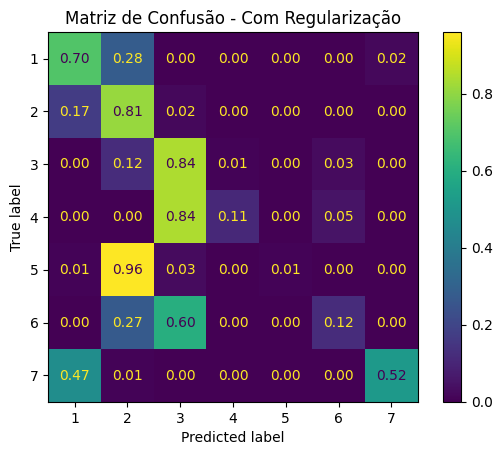

<Figure size 800x600 with 0 Axes>

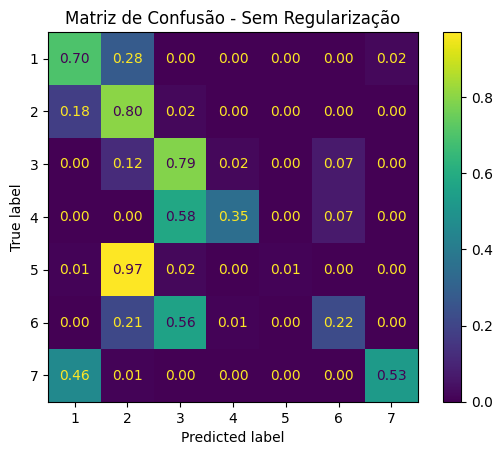

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Matrizes de confusão normalizadas
cm_reg = confusion_matrix(
    y_test,
    y_pred_reg,
    normalize='true'
)

cm_no_reg = confusion_matrix(
    y_test,
    y_pred_no_reg,
    normalize='true'
)

# Arredondando para duas casas
cm_reg = cm_reg.round(2)
cm_no_reg = cm_no_reg.round(2)

print("Matriz normalizada - Com regularização")
print(cm_reg)

print("\nMatriz normalizada - Sem regularização")
print(cm_no_reg)

# Plot da matriz com regularização
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm_reg,
    display_labels=model_final.classes_
).plot(values_format='.2f')
plt.title("Matriz de Confusão - Com Regularização")
plt.show()

# Plot da matriz sem regularização
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm_no_reg,
    display_labels=model_no_reg.classes_
).plot(values_format='.2f')
plt.title("Matriz de Confusão - Sem Regularização")
plt.show()

As matrizes mostram que as classes 1, 2 e 3 foram as mais bem classificadas pelos dois modelos, apresentando maiores valores na diagonal principal. Já as classes 4, 5, 6 e 7 apresentaram mais confusões, principalmente por possuírem menos amostras. A comparação indica que a regularização teve impacto pequeno no desempenho geral, embora o modelo sem regularização tenha apresentado uma leve melhora em algumas classes menos representadas.